In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('df_with_2regimes.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3518 entries, 0 to 3517
Data columns (total 37 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        3518 non-null   object 
 1   log_return                                  3518 non-null   float64
 2   realized_variance                           3518 non-null   float64
 3   realized_volatility                         3518 non-null   float64
 4   gtrend_pct_change                           3518 non-null   float64
 5   blockchain_diff_log_n_transactions          3518 non-null   float64
 6   blockchain_diff_log_transaction_fee_usd     3518 non-null   float64
 7   blockchain_diff_log_n_unique_addresses      3518 non-null   float64
 8   blockchain_diff_log_transaction_volume_usd  3518 non-null   float64
 9   log_volume                                  3518 non-null   float64
 10  target      

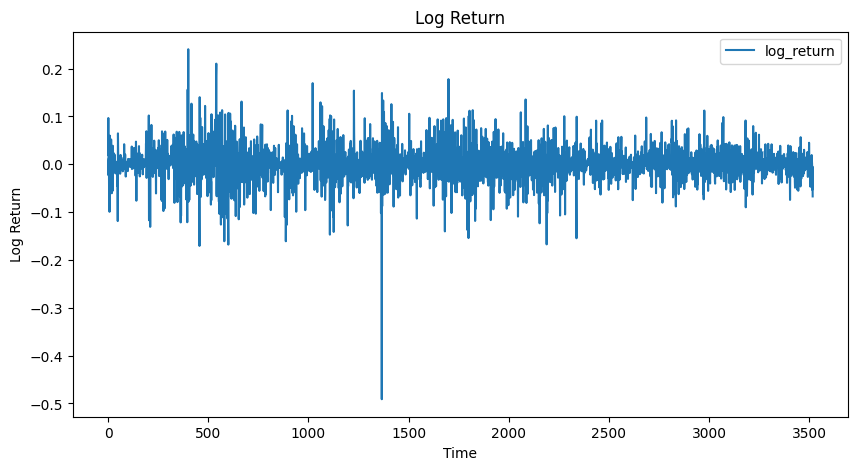

In [5]:
# plot log_return
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(df['log_return'], label='log_return')     
plt.title('Log Return')
plt.xlabel('Time')
plt.ylabel('Log Return')
plt.legend()
plt.show()

In [6]:
# calculate the mean and standard deviation of log_return
mean_log_return = df['log_return'].mean()
variance_log_return = df['log_return'].var()    
print(mean_log_return)
print(variance_log_return)


0.0013483205332999874
0.0013061496600273153


In [7]:
import scipy.stats as stats
import numpy as np

r = df["log_return"].dropna()

mean = r.mean()
std = r.std()
n = len(r)

t_stat = mean / (std / np.sqrt(n))
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=n-1))

print(f"Mean: {mean:.6f}")
print(f"T-stat: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

Mean: 0.001348
T-stat: 2.2128
P-value: 0.026975


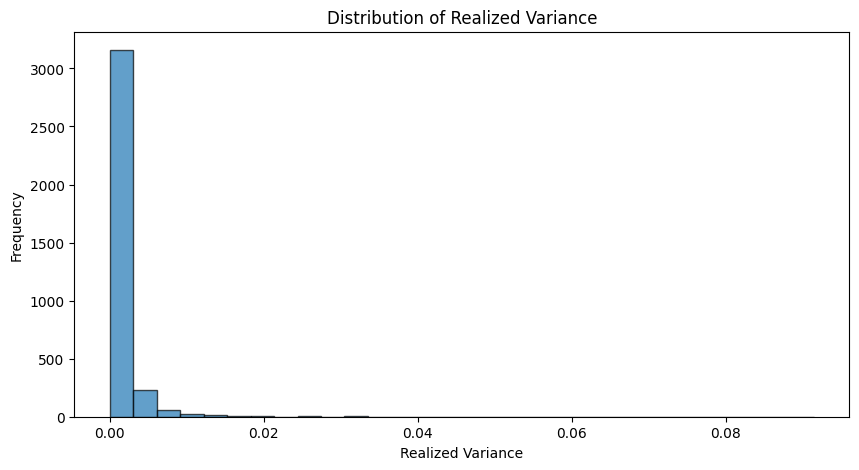

In [8]:
# plot realized variance distribution

plt.figure(figsize=(10, 5))
plt.hist(df['realized_variance'], bins=30, edgecolor='k', alpha=0.7)
plt.title('Distribution of Realized Variance')
plt.xlabel('Realized Variance')
plt.ylabel('Frequency')
plt.show()




(array([  1.,   2.,   8.,   2.,   7.,  12.,  19.,  19.,  23.,  31.,  32.,
         40.,  63.,  62.,  65.,  88., 107., 122., 166., 163., 161., 190.,
        215., 225., 219., 216., 206., 177., 146., 132., 120.,  96.,  78.,
         61.,  72.,  49.,  33.,  27.,  17.,  10.,  13.,   8.,   3.,   4.,
          3.,   2.,   0.,   1.,   1.,   1.]),
 array([-11.95759795, -11.76628271, -11.57496748, -11.38365225,
        -11.19233702, -11.00102179, -10.80970656, -10.61839132,
        -10.42707609, -10.23576086, -10.04444563,  -9.8531304 ,
         -9.66181516,  -9.47049993,  -9.2791847 ,  -9.08786947,
         -8.89655424,  -8.705239  ,  -8.51392377,  -8.32260854,
         -8.13129331,  -7.93997808,  -7.74866284,  -7.55734761,
         -7.36603238,  -7.17471715,  -6.98340192,  -6.79208668,
         -6.60077145,  -6.40945622,  -6.21814099,  -6.02682576,
         -5.83551052,  -5.64419529,  -5.45288006,  -5.26156483,
         -5.0702496 ,  -4.87893436,  -4.68761913,  -4.4963039 ,
         -4.304988

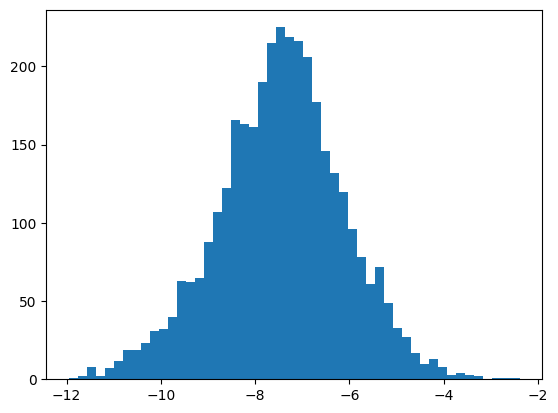

In [9]:
plt.hist(np.log(df["realized_variance"] + 1e-8), bins=50)

In [9]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

def regime_whiteness_test(
    df,
    return_col="log_return",
    regime_col="regime_id",
    regime_value=None,
    lags=20
):
    sub = df[df[regime_col] == regime_value][[return_col]].dropna().copy()
    r = sub[return_col]

    n = len(r)
    mean = r.mean()
    std = r.std(ddof=1)

    t_stat = mean / (std / np.sqrt(n))
    p_mean = 2 * (1 - stats.t.cdf(abs(t_stat), df=n - 1))

    lb = acorr_ljungbox(r, lags=[5, 10, min(lags, max(1, n // 5))], return_df=True)

    print(f"\n=== Regime {regime_value} ===")
    print(f"N: {n}")
    print(f"Mean: {mean:.6f}")
    print(f"T-stat: {t_stat:.4f}")
    print(f"P-value (mean=0): {p_mean:.6f}")
    print("\nLjung-Box:")
    print(lb)

    return {
        "n": n,
        "mean": mean,
        "t_stat": t_stat,
        "p_mean": p_mean,
        "ljung_box": lb
    }

In [10]:
train_size = int(len(df) * 0.7)
eval_size = int(len(df) * 0.15)
train_df = df.iloc[:train_size]

eval_df = df.iloc[train_size:train_size + eval_size]
test_df = df.iloc[train_size + eval_size:]

In [11]:

for k in sorted(train_df["regime_id"].dropna().unique()):
    regime_whiteness_test(
        train_df,
        return_col="log_return",
        regime_col="regime_id",
        regime_value=k,
        lags=20
    )


=== Regime 0.0 ===
N: 1102
Mean: 0.002240
T-stat: 3.0863
P-value (mean=0): 0.002077

Ljung-Box:
      lb_stat  lb_pvalue
5    6.161709   0.290801
10  14.371825   0.156697
20  36.872224   0.012122

=== Regime 1.0 ===
N: 1331
Mean: 0.000793
T-stat: 0.5820
P-value (mean=0): 0.560661

Ljung-Box:
      lb_stat  lb_pvalue
5    8.433990   0.133884
10  15.178236   0.125698
20  30.615712   0.060472


#### test whether x can predict residuals

In [12]:
def regime_x_mean_test(
    df,
    return_col="log_return",
    regime_col="regime_id",
    regime_value=None,
    x_cols=None
):
    cols = [return_col, regime_col] + x_cols
    sub = df[df[regime_col] == regime_value][cols].dropna().copy()

    y = sub[return_col]
    X = sm.add_constant(sub[x_cols])

    model = sm.OLS(y, X).fit()

    print(f"\n=== Regime {regime_value}: return ~ X ===")
    print(model.summary())

    return model

In [13]:
x_cols = [
    "gtrend_pct_change",
    "blockchain_diff_log_n_transactions",
    "blockchain_diff_log_transaction_fee_usd",
    "blockchain_diff_log_n_unique_addresses",
    "blockchain_diff_log_transaction_volume_usd",
    "log_volume",
    "gold_close_ret",
    "silver_close_ret",
    "brent_close_ret",
    "dji_close_ret",
    "spx_close_ret",
    "rut_close_ret",
    "nasdaq_close_ret",
    "usdcny_close_ret",
    "usdeur_close_ret",
    "gold_volume_chg",
    "silver_volume_chg",
    "brent_volume_chg",
    "dji_volume_chg",
    "spx_volume_chg",
    "rut_volume_chg",
    "nasdaq_volume_chg",
    "vix_close_chg",
    "hash-rate_chg",
    "difficulty_chg",
    "median-confirmation-time_chg",
    "blockchain_log_mempool_count_chg"
]

for k in sorted(train_df["regime_id"].dropna().unique()):
    regime_x_mean_test(
        train_df,
        return_col="log_return",
        regime_col="regime_id",
        regime_value=k,
        x_cols=x_cols
    )


=== Regime 0.0: return ~ X ===
                            OLS Regression Results                            
Dep. Variable:             log_return   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     2.884
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           2.18e-06
Time:                        19:05:53   Log-Likelihood:                 2579.9
No. Observations:                1102   AIC:                            -5106.
Df Residuals:                    1075   BIC:                            -4971.
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

<Figure size 1200x500 with 0 Axes>

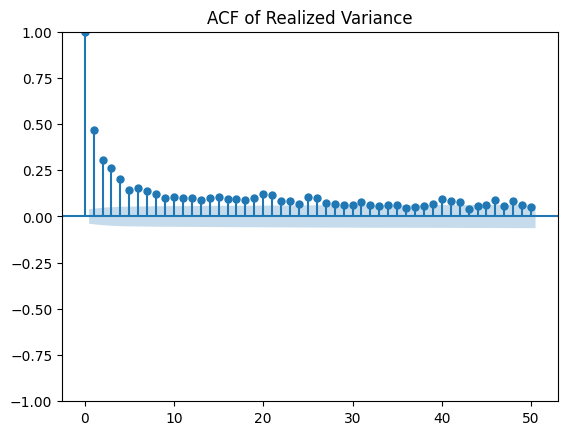

<Figure size 1200x500 with 0 Axes>

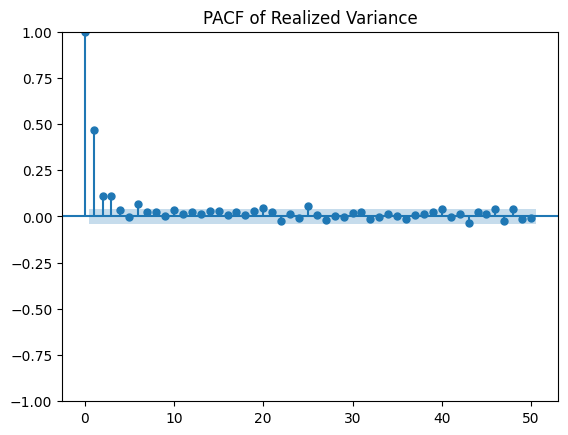

In [14]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# assume df["realized_variance"] exists
rv = train_df["realized_variance"].dropna()

plt.figure(figsize=(12,5))
plot_acf(rv, lags=50)
plt.title("ACF of Realized Variance")
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(rv, lags=50)
plt.title("PACF of Realized Variance")
plt.show()

#### Which distribution to use for GARCH model

In [15]:
import numpy as np
from scipy.stats import kurtosis, jarque_bera
from arch import arch_model


def choose_garch_dist_empirical(returns, p=1, q=1, vol="Garch", min_obs=300):
    returns = returns.dropna().astype(float)

    if len(returns) < min_obs:
        return None, {"reason": "too_few_obs", "n_obs": len(returns)}

    try:
        res_norm = arch_model(
            returns * 100,
            mean="constant",
            vol=vol,
            p=p,
            q=q,
            dist="normal"
        ).fit(disp="off")
    except Exception as e:
        return None, {"reason": "normal_fit_failed", "error": str(e)}

    z = res_norm.std_resid.dropna()

    if len(z) == 0:
        return None, {"reason": "empty_std_resid"}

    k = kurtosis(z, fisher=False, bias=False)   # normal ~ 3
    jb_stat, jb_p = jarque_bera(z)

    # simple empirical rule
    if k > 4 or jb_p < 0.05:
        chosen = "t"
    else:
        chosen = "normal"

    info = {
        "n_obs": len(returns),
        "kurtosis": float(k),
        "jb_pvalue": float(jb_p),
        "chosen_dist": chosen
    }

    return chosen, info

In [16]:
train_returns = train_df["log_return"]
chosen_dist, info = choose_garch_dist_empirical(train_returns)
print(info)

{'n_obs': 2462, 'kurtosis': 15.538260530303042, 'jb_pvalue': 0.0, 'chosen_dist': 't'}
